# Notebook 08: Final Results and Report Figures

This notebook collects the final results from the Dry Bean XAI project.

The previous notebooks completed:

- Data understanding
- Preprocessing
- Model training
- Model evaluation
- SHAP explanations
- LIME explanations
- Explanation stability analysis

### Cell 1 — Imports and Configuration

In [2]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

NOTEBOOK_NAME = "08_final_results_and_report_figures"

MODEL_ORDER = [
    "logistic_regression",
    "decision_tree",
    "random_forest",
    "mlp"
]

MODEL_DISPLAY_NAMES = {
    "logistic_regression": "Logistic Regression",
    "decision_tree": "Decision Tree",
    "random_forest": "Random Forest",
    "mlp": "MLP"
}

MODEL_NAME_ALIASES = {
    "Logistic Regression": "logistic_regression",
    "Decision Tree": "decision_tree",
    "Random Forest": "random_forest",
    "MLP": "mlp",
    "logistic_regression": "logistic_regression",
    "decision_tree": "decision_tree",
    "random_forest": "random_forest",
    "mlp": "mlp"
}


def find_project_root() -> Path:
    current_path = Path.cwd().resolve()

    if current_path.name == "notebooks":
        return current_path.parent

    if (current_path / "data").exists():
        return current_path

    for parent in current_path.parents:
        if (parent / "data").exists():
            return parent

    return current_path


PROJECT_ROOT = find_project_root()

RESULTS_DIR = PROJECT_ROOT / "results" / NOTEBOOK_NAME
PLOTS_DIR = PROJECT_ROOT / "plots" / NOTEBOOK_NAME
REPORT_TABLES_DIR = RESULTS_DIR / "report_tables"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLES_DIR.mkdir(parents=True, exist_ok=True)

EVAL_RESULTS_DIR = PROJECT_ROOT / "results" / "04_model_evaluation"
SHAP_RESULTS_DIR = PROJECT_ROOT / "results" / "05_shap_explanations"
LIME_RESULTS_DIR = PROJECT_ROOT / "results" / "06_lime_explanations"
STABILITY_RESULTS_DIR = PROJECT_ROOT / "results" / "07_explanation_stability"

print(f"Project root: {PROJECT_ROOT}")
print(f"Results directory: {RESULTS_DIR}")
print(f"Plots directory: {PLOTS_DIR}")
print(f"Report tables directory: {REPORT_TABLES_DIR}")

Project root: /home/iailab42/khans1/projects/xai
Results directory: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures
Plots directory: /home/iailab42/khans1/projects/xai/plots/08_final_results_and_report_figures
Report tables directory: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables


### Cell 2 — Helper Functions

In [3]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing CSV file: {path}")

    return pd.read_csv(path)


def load_json(path: Path):
    if not path.exists():
        raise FileNotFoundError(f"Missing JSON file: {path}")

    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def save_json(data: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)

    with open(path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=4)


def normalize_model_name(model_name):
    return MODEL_NAME_ALIASES.get(model_name, model_name)


def add_display_name(df: pd.DataFrame, model_column: str = "model_name") -> pd.DataFrame:
    output_df = df.copy()

    output_df[model_column] = output_df[model_column].apply(normalize_model_name)
    output_df["display_name"] = output_df[model_column].map(MODEL_DISPLAY_NAMES)

    return output_df


def sort_by_model_order(df: pd.DataFrame, model_column: str = "model_name") -> pd.DataFrame:
    output_df = df.copy()

    output_df[model_column] = output_df[model_column].apply(normalize_model_name)
    output_df["model_order"] = output_df[model_column].apply(
        lambda value: MODEL_ORDER.index(value) if value in MODEL_ORDER else 999
    )

    output_df = output_df.sort_values(by="model_order").drop(columns=["model_order"])

    return output_df.reset_index(drop=True)


def save_table(df: pd.DataFrame, filename: str) -> Path:
    path = REPORT_TABLES_DIR / filename
    df.to_csv(path, index=False)
    print(f"Saved table: {path}")
    return path


def save_plot(path: Path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {path}")

### Cell 3 — Load Saved Results from Previous Notebooks

In [4]:
evaluation_metrics = load_csv(EVAL_RESULTS_DIR / "evaluation_metrics.csv")
classwise_performance = load_csv(EVAL_RESULTS_DIR / "classwise_performance.csv")
top_confusion_pairs = load_csv(EVAL_RESULTS_DIR / "top_confusion_pairs.csv")

shap_feature_importance = load_csv(SHAP_RESULTS_DIR / "shap_feature_importance_all_models.csv")
lime_feature_importance = load_csv(LIME_RESULTS_DIR / "lime_feature_importance_all_models.csv")

shap_lime_agreement = load_csv(
    STABILITY_RESULTS_DIR / "shap_lime_method_agreement_summary_by_model.csv"
)

cross_model_stability = load_csv(
    STABILITY_RESULTS_DIR / "cross_model_stability_summary.csv"
)

within_group_stability = load_csv(
    STABILITY_RESULTS_DIR / "within_group_stability_summary.csv"
)

nearest_neighbor_stability = load_csv(
    STABILITY_RESULTS_DIR / "nearest_neighbor_stability_summary.csv"
)

overall_stability_summary = load_csv(
    STABILITY_RESULTS_DIR / "overall_stability_summary.csv"
)

dermason_sira_stability = load_json(
    STABILITY_RESULTS_DIR / "dermason_sira_stability_summary.json"
)

explanation_stability_summary = load_json(
    STABILITY_RESULTS_DIR / "explanation_stability_summary.json"
)

print("All required files loaded successfully.")

print(f"evaluation_metrics: {evaluation_metrics.shape}")
print(f"classwise_performance: {classwise_performance.shape}")
print(f"top_confusion_pairs: {top_confusion_pairs.shape}")
print(f"shap_feature_importance: {shap_feature_importance.shape}")
print(f"lime_feature_importance: {lime_feature_importance.shape}")
print(f"overall_stability_summary: {overall_stability_summary.shape}")

All required files loaded successfully.
evaluation_metrics: (4, 6)
classwise_performance: (28, 7)
top_confusion_pairs: (87, 6)
shap_feature_importance: (64, 5)
lime_feature_importance: (64, 7)
overall_stability_summary: (4, 7)


### Cell 4 — Prepare Final Model Performance Table

In [5]:
performance_df = evaluation_metrics.copy()

if "model_name" not in performance_df.columns:
    possible_model_columns = ["Model", "model", "display_name"]
    found_column = None

    for column in possible_model_columns:
        if column in performance_df.columns:
            found_column = column
            break

    if found_column is None:
        raise ValueError("Could not find model name column in evaluation_metrics.csv")

    performance_df = performance_df.rename(columns={found_column: "model_name"})

performance_df["model_name"] = performance_df["model_name"].apply(normalize_model_name)
performance_df["display_name"] = performance_df["model_name"].map(MODEL_DISPLAY_NAMES)

performance_df = sort_by_model_order(performance_df, model_column="model_name")

metric_columns = [
    column for column in [
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_weighted"
    ]
    if column in performance_df.columns
]

final_performance_table = performance_df[
    ["model_name", "display_name"] + metric_columns
].copy()

for column in metric_columns:
    final_performance_table[column] = final_performance_table[column].round(4)

save_table(final_performance_table, "final_model_performance.csv")

display(final_performance_table)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/final_model_performance.csv


,model_name,display_name,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,logistic_regression,Logistic Regression,0.9192,0.9307,0.9300,0.9302,0.9193
1,decision_tree,Decision Tree,0.8955,0.9094,0.9104,0.9098,0.8953
2,random_forest,Random Forest,0.9192,0.9314,0.9289,0.9301,0.9191
3,mlp,MLP,0.9251,0.9359,0.9346,0.9351,0.9251


### Cell 5 — Plot Final Model Performance

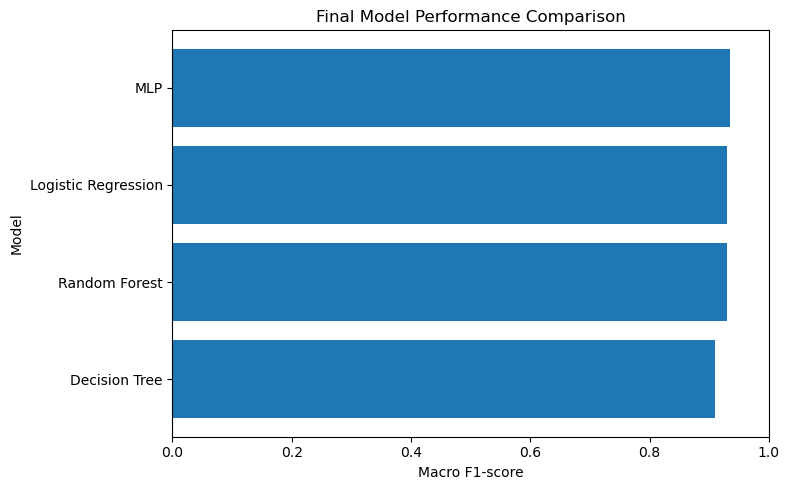

Saved plot: /home/iailab42/khans1/projects/xai/plots/08_final_results_and_report_figures/final_model_macro_f1_comparison.png


In [6]:
plot_df = final_performance_table.sort_values(by="f1_macro", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["display_name"], plot_df["f1_macro"])
plt.xlabel("Macro F1-score")
plt.ylabel("Model")
plt.title("Final Model Performance Comparison")
plt.xlim(0, 1)

save_plot(PLOTS_DIR / "final_model_macro_f1_comparison.png")

### Cell 6 — Prepare Top SHAP and LIME Feature Tables

In [7]:
def prepare_top_feature_table(
    importance_df: pd.DataFrame,
    value_column: str,
    method_name: str,
    top_n: int = 5
) -> pd.DataFrame:
    df = importance_df.copy()
    df["model_name"] = df["model_name"].apply(normalize_model_name)
    df["display_name"] = df["model_name"].map(MODEL_DISPLAY_NAMES)

    if "rank" not in df.columns:
        df["rank"] = (
            df
            .groupby("model_name")[value_column]
            .rank(method="first", ascending=False)
            .astype(int)
        )

    top_df = df[df["rank"] <= top_n].copy()
    top_df["method"] = method_name

    top_df = top_df.sort_values(by=["model_name", "rank"]).reset_index(drop=True)

    return top_df[
        [
            "method",
            "model_name",
            "display_name",
            "rank",
            "feature",
            value_column
        ]
    ]


top_shap_features = prepare_top_feature_table(
    importance_df=shap_feature_importance,
    value_column="mean_abs_shap",
    method_name="SHAP",
    top_n=5
)

top_lime_features = prepare_top_feature_table(
    importance_df=lime_feature_importance,
    value_column="mean_abs_lime_weight",
    method_name="LIME",
    top_n=5
)

save_table(top_shap_features, "top_5_shap_features_by_model.csv")
save_table(top_lime_features, "top_5_lime_features_by_model.csv")

display(top_shap_features)
display(top_lime_features)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/top_5_shap_features_by_model.csv
Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/top_5_lime_features_by_model.csv


,method,model_name,display_name,rank,feature,mean_abs_shap
0,SHAP,decision_tree,Decision Tree,1,MajorAxisLength,0.085811
1,SHAP,decision_tree,Decision Tree,2,Perimeter,0.069993
2,SHAP,decision_tree,Decision Tree,3,ShapeFactor1,0.053046
3,SHAP,decision_tree,Decision Tree,4,Compactness,0.034433
4,SHAP,decision_tree,Decision Tree,5,roundness,0.029426
5,SHAP,logistic_regression,Logistic Regression,1,ShapeFactor1,1.377006
6,SHAP,logistic_regression,Logistic Regression,2,MinorAxisLength,1.035575
7,SHAP,logistic_regression,Logistic Regression,3,EquivDiameter,0.852944
8,SHAP,logistic_regression,Logistic Regression,4,Perimeter,0.851588
9,SHAP,logistic_regression,Logistic Regression,5,ConvexArea,0.752849


,method,model_name,display_name,rank,feature,mean_abs_lime_weight
0,LIME,decision_tree,Decision Tree,1,Perimeter,0.113066
1,LIME,decision_tree,Decision Tree,2,MajorAxisLength,0.066178
2,LIME,decision_tree,Decision Tree,3,MinorAxisLength,0.043609
3,LIME,decision_tree,Decision Tree,4,ShapeFactor1,0.037935
4,LIME,decision_tree,Decision Tree,5,roundness,0.031857
5,LIME,logistic_regression,Logistic Regression,1,ShapeFactor1,0.107108
6,LIME,logistic_regression,Logistic Regression,2,Perimeter,0.052903
7,LIME,logistic_regression,Logistic Regression,3,EquivDiameter,0.049299
8,LIME,logistic_regression,Logistic Regression,4,MinorAxisLength,0.047433
9,LIME,logistic_regression,Logistic Regression,5,MajorAxisLength,0.045067


### Cell 7 — Create Combined Top Feature Summary

In [8]:
shap_features_for_summary = top_shap_features.rename(
    columns={"mean_abs_shap": "importance_value"}
)

lime_features_for_summary = top_lime_features.rename(
    columns={"mean_abs_lime_weight": "importance_value"}
)

combined_top_features = pd.concat(
    [shap_features_for_summary, lime_features_for_summary],
    ignore_index=True
)

combined_top_features["importance_value"] = combined_top_features["importance_value"].round(6)

save_table(combined_top_features, "combined_top_5_xai_features.csv")

display(combined_top_features)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/combined_top_5_xai_features.csv


,method,model_name,display_name,rank,feature,importance_value
0,SHAP,decision_tree,Decision Tree,1,MajorAxisLength,0.085811
1,SHAP,decision_tree,Decision Tree,2,Perimeter,0.069993
2,SHAP,decision_tree,Decision Tree,3,ShapeFactor1,0.053046
3,SHAP,decision_tree,Decision Tree,4,Compactness,0.034433
4,SHAP,decision_tree,Decision Tree,5,roundness,0.029426
5,SHAP,logistic_regression,Logistic Regression,1,ShapeFactor1,1.377006
6,SHAP,logistic_regression,Logistic Regression,2,MinorAxisLength,1.035575
7,SHAP,logistic_regression,Logistic Regression,3,EquivDiameter,0.852944
8,SHAP,logistic_regression,Logistic Regression,4,Perimeter,0.851588
9,SHAP,logistic_regression,Logistic Regression,5,ConvexArea,0.752849


### Cell 8 — Plot Top SHAP and LIME Feature Frequency

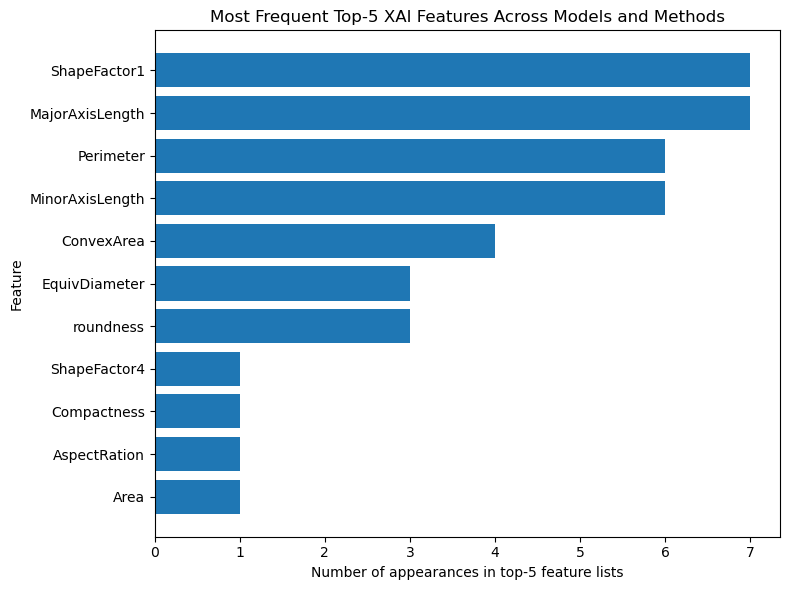

Saved plot: /home/iailab42/khans1/projects/xai/plots/08_final_results_and_report_figures/top_5_xai_feature_frequency.png
Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/top_5_xai_feature_frequency.csv


PosixPath('/home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/top_5_xai_feature_frequency.csv')

In [9]:
feature_frequency = (
    combined_top_features
    .groupby("feature", as_index=False)
    .agg(top_5_count=("feature", "count"))
    .sort_values(by="top_5_count", ascending=True)
)

plt.figure(figsize=(8, 6))
plt.barh(feature_frequency["feature"], feature_frequency["top_5_count"])
plt.xlabel("Number of appearances in top-5 feature lists")
plt.ylabel("Feature")
plt.title("Most Frequent Top-5 XAI Features Across Models and Methods")

save_plot(PLOTS_DIR / "top_5_xai_feature_frequency.png")

save_table(feature_frequency.sort_values(by="top_5_count", ascending=False), "top_5_xai_feature_frequency.csv")

### Cell 9 — Prepare Final SHAP vs LIME Agreement Table

In [10]:
method_agreement_df = shap_lime_agreement.copy()
method_agreement_df["model_name"] = method_agreement_df["model_name"].apply(normalize_model_name)
method_agreement_df["display_name"] = method_agreement_df["model_name"].map(MODEL_DISPLAY_NAMES)

method_agreement_df = sort_by_model_order(method_agreement_df, model_column="model_name")

agreement_columns = [
    "model_name",
    "display_name",
    "mean_top_k_overlap",
    "mean_jaccard_similarity",
    "mean_rank_correlation",
    "mean_abs_cosine_similarity",
    "n_comparisons"
]

available_agreement_columns = [
    column for column in agreement_columns
    if column in method_agreement_df.columns
]

final_method_agreement_table = method_agreement_df[available_agreement_columns].copy()

for column in final_method_agreement_table.select_dtypes(include=[np.number]).columns:
    if column != "n_comparisons":
        final_method_agreement_table[column] = final_method_agreement_table[column].round(4)

save_table(final_method_agreement_table, "final_shap_lime_agreement_by_model.csv")

display(final_method_agreement_table)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/final_shap_lime_agreement_by_model.csv


,model_name,display_name,mean_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_abs_cosine_similarity,n_comparisons
0,logistic_regression,Logistic Regression,0.695,0.5697,0.2989,0.7329,40
1,decision_tree,Decision Tree,0.510,0.3683,-0.0164,0.5349,40
2,random_forest,Random Forest,0.600,0.4657,0.0156,0.6093,40
3,mlp,MLP,0.530,0.3932,-0.1028,0.5724,40


### Cell 10 — Plot Final SHAP vs LIME Agreement

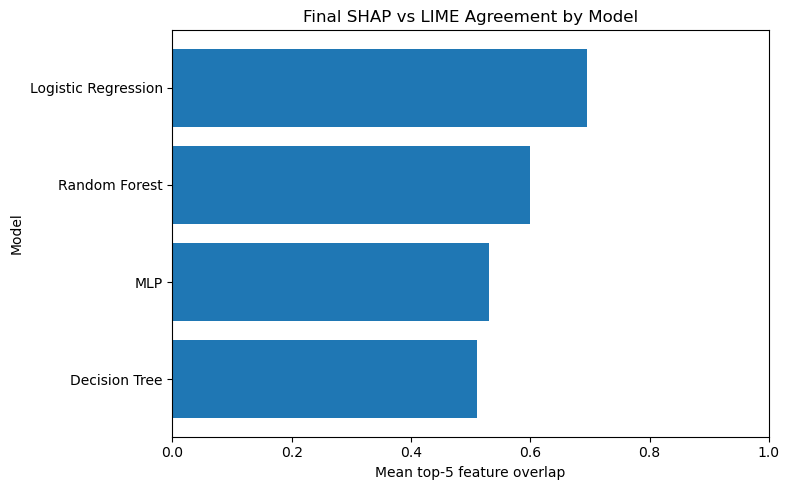

Saved plot: /home/iailab42/khans1/projects/xai/plots/08_final_results_and_report_figures/final_shap_lime_agreement_by_model.png


In [11]:
plot_df = final_method_agreement_table.sort_values(by="mean_top_k_overlap", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["display_name"], plot_df["mean_top_k_overlap"])
plt.xlabel("Mean top-5 feature overlap")
plt.ylabel("Model")
plt.title("Final SHAP vs LIME Agreement by Model")
plt.xlim(0, 1)

save_plot(PLOTS_DIR / "final_shap_lime_agreement_by_model.png")

### Cell 11 — Prepare Overall Stability Summary Table

In [12]:
final_overall_stability = overall_stability_summary.copy()

for column in final_overall_stability.select_dtypes(include=[np.number]).columns:
    if "n_" not in column:
        final_overall_stability[column] = final_overall_stability[column].round(4)

save_table(final_overall_stability, "final_overall_stability_summary.csv")

display(final_overall_stability)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/final_overall_stability_summary.csv


,analysis,mean_top_k_overlap,std_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_abs_cosine_similarity,n_comparisons
0,SHAP vs LIME method agreement,0.583750,0.2287,0.449206,0.048828,0.612342,160
1,Cross-model stability,0.460833,0.2119,0.325141,-0.287796,0.443638,480
2,Within-group stability,0.598092,0.2327,0.467694,0.073991,0.626914,1048
3,Nearest-neighbor stability,0.629375,0.2284,0.501563,0.129714,0.659615,320


### Cell 12 — Plot Overall Stability Summary

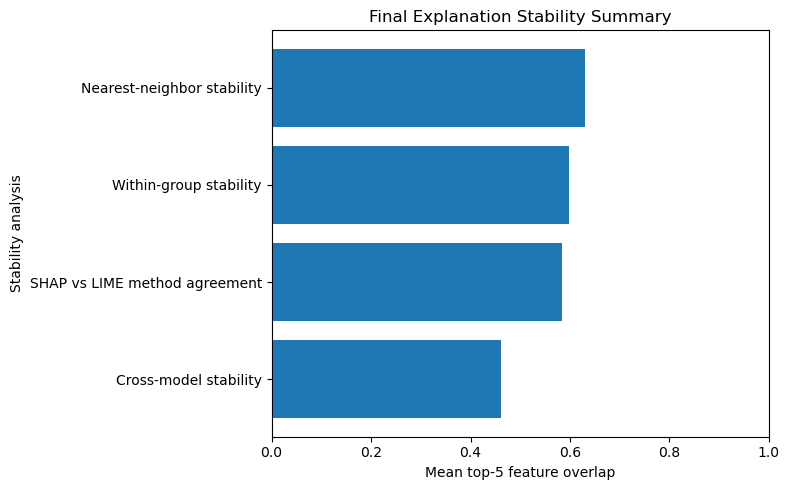

Saved plot: /home/iailab42/khans1/projects/xai/plots/08_final_results_and_report_figures/final_overall_stability_summary.png


In [13]:
plot_df = final_overall_stability.sort_values(by="mean_top_k_overlap", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["analysis"], plot_df["mean_top_k_overlap"])
plt.xlabel("Mean top-5 feature overlap")
plt.ylabel("Stability analysis")
plt.title("Final Explanation Stability Summary")
plt.xlim(0, 1)

save_plot(PLOTS_DIR / "final_overall_stability_summary.png")

### Cell 13 — Prepare Nearest-Neighbor Stability Table

In [14]:
nearest_table = nearest_neighbor_stability.copy()
nearest_table["model_name"] = nearest_table["model_name"].apply(normalize_model_name)
nearest_table["display_name"] = nearest_table["model_name"].map(MODEL_DISPLAY_NAMES)

nearest_table["model_method"] = nearest_table["display_name"] + " - " + nearest_table["method"]

nearest_columns = [
    "method",
    "model_name",
    "display_name",
    "model_method",
    "mean_feature_distance",
    "mean_top_k_overlap",
    "mean_jaccard_similarity",
    "mean_rank_correlation",
    "mean_abs_cosine_similarity",
    "n_pairs"
]

available_nearest_columns = [
    column for column in nearest_columns
    if column in nearest_table.columns
]

final_nearest_table = nearest_table[available_nearest_columns].copy()

for column in final_nearest_table.select_dtypes(include=[np.number]).columns:
    if column != "n_pairs":
        final_nearest_table[column] = final_nearest_table[column].round(4)

final_nearest_table = final_nearest_table.sort_values(
    by="mean_top_k_overlap",
    ascending=False
).reset_index(drop=True)

save_table(final_nearest_table, "final_nearest_neighbor_stability.csv")

display(final_nearest_table)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/final_nearest_neighbor_stability.csv


,method,model_name,display_name,model_method,mean_feature_distance,mean_top_k_overlap,mean_jaccard_similarity,mean_rank_correlation,mean_abs_cosine_similarity,n_pairs
0,SHAP,logistic_regression,Logistic Regression,Logistic Regression - SHAP,1.324,0.775,0.6888,0.3714,0.8009,40
1,LIME,random_forest,Random Forest,Random Forest - LIME,1.324,0.730,0.6124,0.2121,0.7458,40
2,SHAP,random_forest,Random Forest,Random Forest - SHAP,1.324,0.640,0.5024,0.0590,0.6256,40
3,LIME,mlp,MLP,MLP - LIME,1.324,0.605,0.4866,0.1221,0.6072,40
4,SHAP,decision_tree,Decision Tree,Decision Tree - SHAP,1.324,0.595,0.4662,0.0389,0.5919,40
5,SHAP,mlp,MLP,MLP - SHAP,1.324,0.595,0.4437,0.0993,0.6361,40
6,LIME,logistic_regression,Logistic Regression,Logistic Regression - LIME,1.324,0.590,0.4546,0.0191,0.6085,40
7,LIME,decision_tree,Decision Tree,Decision Tree - LIME,1.324,0.505,0.3579,0.1159,0.6610,40


### Cell 14 — Plot Final Nearest-Neighbor Stability

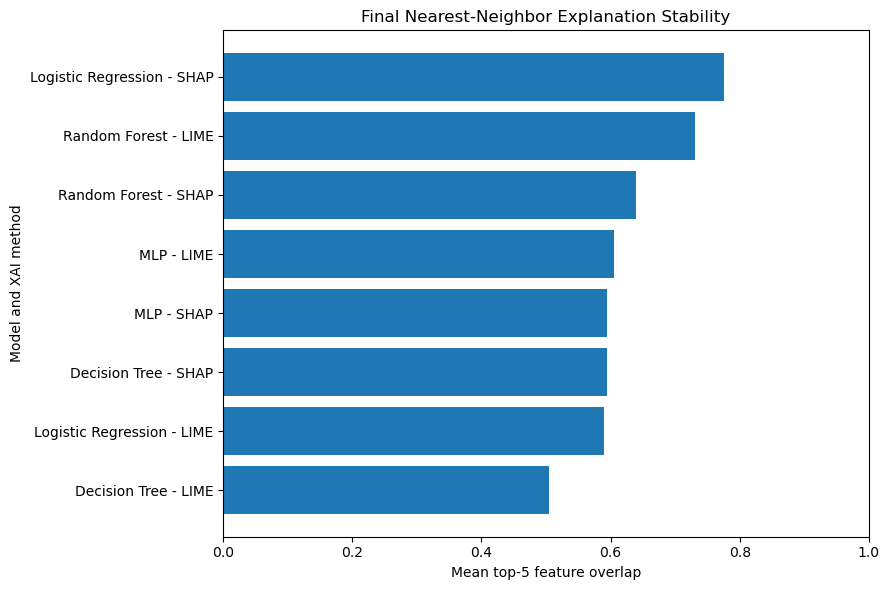

Saved plot: /home/iailab42/khans1/projects/xai/plots/08_final_results_and_report_figures/final_nearest_neighbor_stability.png


In [15]:
plot_df = final_nearest_table.sort_values(by="mean_top_k_overlap", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(plot_df["model_method"], plot_df["mean_top_k_overlap"])
plt.xlabel("Mean top-5 feature overlap")
plt.ylabel("Model and XAI method")
plt.title("Final Nearest-Neighbor Explanation Stability")
plt.xlim(0, 1)

save_plot(PLOTS_DIR / "final_nearest_neighbor_stability.png")

### Cell 15 — Prepare DERMASON/SIRA Focused Summary Table

In [16]:
dermason_sira_rows = []

for analysis_name, values in dermason_sira_stability.items():
    row = {
        "analysis": analysis_name,
        "mean_top_k_overlap": values.get("mean_top_k_overlap", np.nan),
        "mean_abs_cosine_similarity": values.get("mean_abs_cosine_similarity", np.nan)
    }

    if "n_comparisons" in values:
        row["n"] = values["n_comparisons"]
    elif "n_pairs" in values:
        row["n"] = values["n_pairs"]
    else:
        row["n"] = np.nan

    dermason_sira_rows.append(row)

final_dermason_sira_table = pd.DataFrame(dermason_sira_rows)

for column in final_dermason_sira_table.select_dtypes(include=[np.number]).columns:
    if column != "n":
        final_dermason_sira_table[column] = final_dermason_sira_table[column].round(4)

save_table(final_dermason_sira_table, "final_dermason_sira_stability.csv")

display(final_dermason_sira_table)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/final_dermason_sira_stability.csv


,analysis,mean_top_k_overlap,mean_abs_cosine_similarity,n
0,method_agreement,0.5609,0.5901,128
1,within_group_stability,0.5830,0.6097,920
2,nearest_neighbor_stability,0.6070,0.6374,256


### Cell 16 — Plot DERMASON/SIRA Stability

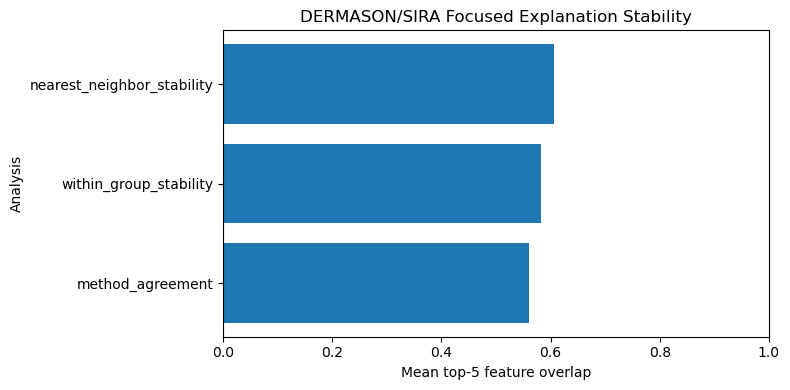

Saved plot: /home/iailab42/khans1/projects/xai/plots/08_final_results_and_report_figures/final_dermason_sira_stability.png


In [17]:
plot_df = final_dermason_sira_table.sort_values(by="mean_top_k_overlap", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["analysis"], plot_df["mean_top_k_overlap"])
plt.xlabel("Mean top-5 feature overlap")
plt.ylabel("Analysis")
plt.title("DERMASON/SIRA Focused Explanation Stability")
plt.xlim(0, 1)

save_plot(PLOTS_DIR / "final_dermason_sira_stability.png")

### Cell 17 — Create Final Key Findings Table

In [18]:
best_performance_row = final_performance_table.sort_values(
    by="f1_macro",
    ascending=False
).iloc[0]

best_method_agreement_row = final_method_agreement_table.sort_values(
    by="mean_top_k_overlap",
    ascending=False
).iloc[0]

best_nearest_row = final_nearest_table.sort_values(
    by="mean_top_k_overlap",
    ascending=False
).iloc[0]

strongest_stability_row = final_overall_stability.sort_values(
    by="mean_top_k_overlap",
    ascending=False
).iloc[0]

weakest_stability_row = final_overall_stability.sort_values(
    by="mean_top_k_overlap",
    ascending=True
).iloc[0]

final_key_findings = pd.DataFrame([
    {
        "finding_area": "Best predictive model",
        "main_result": best_performance_row["display_name"],
        "supporting_value": f"Macro F1 = {best_performance_row['f1_macro']:.4f}",
        "interpretation": "This model achieved the strongest classification performance."
    },
    {
        "finding_area": "Best SHAP vs LIME agreement",
        "main_result": best_method_agreement_row["display_name"],
        "supporting_value": f"Top-5 overlap = {best_method_agreement_row['mean_top_k_overlap']:.4f}",
        "interpretation": "This model produced the most consistent explanations across SHAP and LIME."
    },
    {
        "finding_area": "Best nearest-neighbor stability",
        "main_result": best_nearest_row["model_method"],
        "supporting_value": f"Top-5 overlap = {best_nearest_row['mean_top_k_overlap']:.4f}",
        "interpretation": "This model-method combination produced the most similar explanations for nearby samples."
    },
    {
        "finding_area": "Strongest stability analysis",
        "main_result": strongest_stability_row["analysis"],
        "supporting_value": f"Top-5 overlap = {strongest_stability_row['mean_top_k_overlap']:.4f}",
        "interpretation": "This analysis showed the strongest explanation consistency."
    },
    {
        "finding_area": "Weakest stability analysis",
        "main_result": weakest_stability_row["analysis"],
        "supporting_value": f"Top-5 overlap = {weakest_stability_row['mean_top_k_overlap']:.4f}",
        "interpretation": "This analysis showed the weakest explanation consistency."
    }
])

save_table(final_key_findings, "final_key_findings.csv")

display(final_key_findings)

Saved table: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/report_tables/final_key_findings.csv


,finding_area,main_result,supporting_value,interpretation
0,Best predictive model,MLP,Macro F1 = 0.9351,This model achieved the strongest classificati...
1,Best SHAP vs LIME agreement,Logistic Regression,Top-5 overlap = 0.6950,This model produced the most consistent explan...
2,Best nearest-neighbor stability,Logistic Regression - SHAP,Top-5 overlap = 0.7750,This model-method combination produced the mos...
3,Strongest stability analysis,Nearest-neighbor stability,Top-5 overlap = 0.6294,This analysis showed the strongest explanation...
4,Weakest stability analysis,Cross-model stability,Top-5 overlap = 0.4608,This analysis showed the weakest explanation c...


In [19]:
final_report_notes = f"""# Final Results Summary

## Main Project Objective

The main objective of this project was to evaluate explanation stability in Dry Bean classification. The project did not only compare model accuracy; it also investigated whether similar samples receive similar and stable explanations across models and XAI methods.

## Best Predictive Model

The best predictive model was **{best_performance_row["display_name"]}**, with a macro F1-score of **{best_performance_row["f1_macro"]:.4f}**.

## Best SHAP vs LIME Agreement

The strongest SHAP vs LIME agreement was achieved by **{best_method_agreement_row["display_name"]}**, with a mean top-5 feature overlap of **{best_method_agreement_row["mean_top_k_overlap"]:.4f}**.

## Best Nearest-Neighbor Stability

The strongest nearest-neighbor explanation stability was achieved by **{best_nearest_row["model_method"]}**, with a mean top-5 feature overlap of **{best_nearest_row["mean_top_k_overlap"]:.4f}**.

## Overall Stability Finding

The strongest overall stability analysis was **{strongest_stability_row["analysis"]}**, with a mean top-5 overlap of **{strongest_stability_row["mean_top_k_overlap"]:.4f}**.

The weakest overall stability analysis was **{weakest_stability_row["analysis"]}**, with a mean top-5 overlap of **{weakest_stability_row["mean_top_k_overlap"]:.4f}**.

## Main Conclusion

The results show that explanation stability exists, but it is uneven. Similar samples tend to receive more similar explanations, especially in nearest-neighbor analysis. However, explanations differ more strongly across models.

The main conclusion is that high classification performance does not automatically guarantee stable explanations. Explanation stability should therefore be evaluated separately from model accuracy.
"""

report_notes_path = RESULTS_DIR / "final_report_notes.md"

with open(report_notes_path, "w", encoding="utf-8") as file:
    file.write(final_report_notes)

print(f"Saved final report notes: {report_notes_path}")
print(final_report_notes)

Saved final report notes: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/final_report_notes.md
# Final Results Summary

## Main Project Objective

The main objective of this project was to evaluate explanation stability in Dry Bean classification. The project did not only compare model accuracy; it also investigated whether similar samples receive similar and stable explanations across models and XAI methods.

## Best Predictive Model

The best predictive model was **MLP**, with a macro F1-score of **0.9351**.

## Best SHAP vs LIME Agreement

The strongest SHAP vs LIME agreement was achieved by **Logistic Regression**, with a mean top-5 feature overlap of **0.6950**.

## Best Nearest-Neighbor Stability

The strongest nearest-neighbor explanation stability was achieved by **Logistic Regression - SHAP**, with a mean top-5 feature overlap of **0.7750**.

## Overall Stability Finding

The strongest overall stability analysis was **Nearest-neighbor stability*

In [20]:
final_summary = {
    "notebook": NOTEBOOK_NAME,
    "random_state": RANDOM_STATE,
    "purpose": "Collect final model performance, XAI explanation, and explanation stability outputs for report-ready tables and figures.",
    "input_result_folders": {
        "model_evaluation": "results/04_model_evaluation",
        "shap_explanations": "results/05_shap_explanations",
        "lime_explanations": "results/06_lime_explanations",
        "explanation_stability": "results/07_explanation_stability"
    },
    "key_findings": {
        "best_predictive_model": {
            "model": best_performance_row["display_name"],
            "macro_f1": float(best_performance_row["f1_macro"])
        },
        "best_shap_lime_agreement": {
            "model": best_method_agreement_row["display_name"],
            "mean_top_k_overlap": float(best_method_agreement_row["mean_top_k_overlap"])
        },
        "best_nearest_neighbor_stability": {
            "model_method": best_nearest_row["model_method"],
            "mean_top_k_overlap": float(best_nearest_row["mean_top_k_overlap"])
        },
        "strongest_stability_analysis": {
            "analysis": strongest_stability_row["analysis"],
            "mean_top_k_overlap": float(strongest_stability_row["mean_top_k_overlap"])
        },
        "weakest_stability_analysis": {
            "analysis": weakest_stability_row["analysis"],
            "mean_top_k_overlap": float(weakest_stability_row["mean_top_k_overlap"])
        }
    },
    "saved_outputs": {
        "report_tables_dir": str(REPORT_TABLES_DIR),
        "plots_dir": str(PLOTS_DIR),
        "final_report_notes": str(report_notes_path)
    }
}

summary_path = RESULTS_DIR / "final_results_summary.json"
save_json(final_summary, summary_path)

print(f"Saved final summary: {summary_path}")

Saved final summary: /home/iailab42/khans1/projects/xai/results/08_final_results_and_report_figures/final_results_summary.json


In [21]:
print("Notebook 08 completed.")

print("\nSaved report tables:")
for path in sorted(REPORT_TABLES_DIR.glob("*.csv")):
    print(path.name)

print("\nSaved plots:")
for path in sorted(PLOTS_DIR.glob("*.png")):
    print(path.name)

print("\nSaved result files:")
for path in sorted(RESULTS_DIR.glob("*")):
    if path.is_file():
        print(path.name)

Notebook 08 completed.

Saved report tables:
combined_top_5_xai_features.csv
final_dermason_sira_stability.csv
final_key_findings.csv
final_model_performance.csv
final_nearest_neighbor_stability.csv
final_overall_stability_summary.csv
final_shap_lime_agreement_by_model.csv
top_5_lime_features_by_model.csv
top_5_shap_features_by_model.csv
top_5_xai_feature_frequency.csv

Saved plots:
final_dermason_sira_stability.png
final_model_macro_f1_comparison.png
final_nearest_neighbor_stability.png
final_overall_stability_summary.png
final_shap_lime_agreement_by_model.png
top_5_xai_feature_frequency.png

Saved result files:
final_report_notes.md
final_results_summary.json
